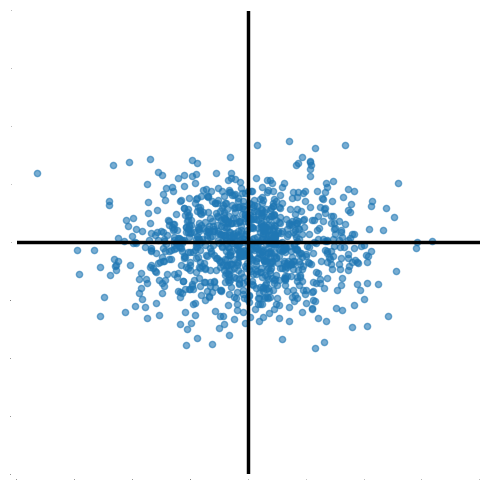

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu_x, mu_y = 0.0, 0.0
sigma_x, sigma_y = 1.0, 0.6
n_points = 1000
xlim = (-4, 4)
ylim = (-4, 4)

rng = np.random.default_rng(42)
x = rng.normal(mu_x, sigma_x, n_points)
y = rng.normal(mu_y, sigma_y, n_points)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, alpha=0.6, s=20)

# Hide the rectangular border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Draw bold X and Y axes through (0, 0)
ax.axhline(0, color='black', linewidth=2.5)
ax.axvline(0, color='black', linewidth=2.5)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.tick_params(length=0, labelsize=0)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()

plt.savefig('erank1p5.png', dpi=300)

plt.show()

In [24]:
val['train_loss_epoch']

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
29   NaN
30   NaN
31   NaN
32   NaN
33   NaN
34   NaN
35   NaN
36   NaN
37   NaN
Name: train_loss_epoch, dtype: float64

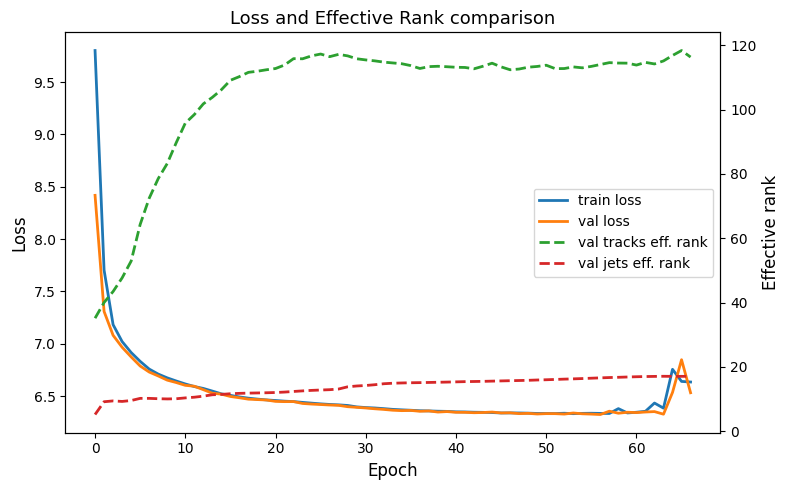

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters ---
csv_path  = '../slurm/pretraining/run_20260320_112055/outputs/model_0_colrow/version_0/metrics.csv'
max_epoch = None   # set to an int to cut the plot, e.g. max_epoch = 20

df = pd.read_csv(csv_path)

# Per-epoch rows (val metrics are logged once per epoch)
val = df[df['val_loss'].notna()][
    ['epoch', 'val_loss',
     'val_tracks/effective_rank', 'val_jets/effective_rank']
].reset_index(drop=True)

train = df[df['train_loss_epoch'].notna()][
    ['epoch', 'train_loss_epoch']
].reset_index(drop=True)

if max_epoch is not None:
    val   = val[val['epoch']     <= max_epoch]
    train = train[train['epoch'] <= max_epoch]

epochs = val['epoch']

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Left axis: losses ---
color_train = '#1f77b4'
color_val   = '#ff7f0e'
l1, = ax1.plot(train['epoch'], train['train_loss_epoch'], color=color_train, lw=2, label='train loss')
l2, = ax1.plot(epochs,         val['val_loss'],           color=color_val,   lw=2, label='val loss')
ax1.set_ylabel('Loss', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis: effective ranks ---
ax2 = ax1.twinx()
color_tracks = "#2ca030"
color_jets   = '#d62728'
l3, = ax2.plot(epochs, val['val_tracks/effective_rank'], color=color_tracks, lw=2, ls='--', label='val tracks eff. rank')
l4, = ax2.plot(epochs, val['val_jets/effective_rank'],   color=color_jets,   lw=2, ls='--', label='val jets eff. rank')
ax2.set_ylabel('Effective rank', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_title('Loss and Effective Rank comparison', fontsize=13)

lines = [l1, l2, l3, l4]
ax1.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig('effective_rank.png', dpi=300)
plt.show()


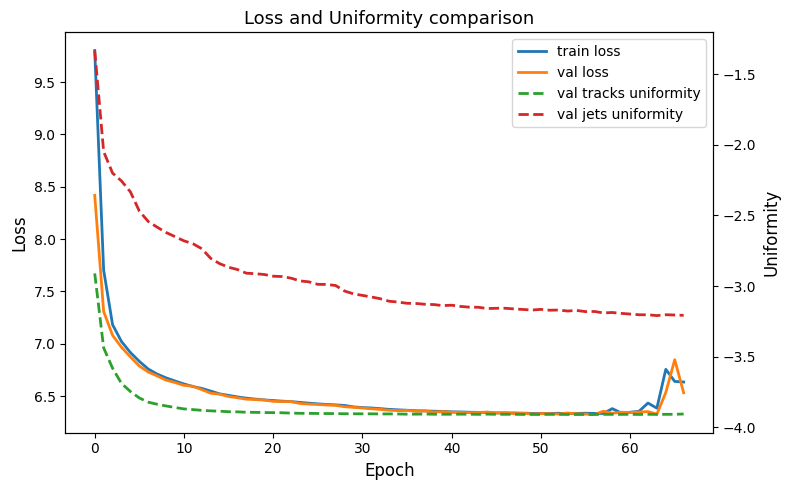

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters ---
csv_path  = '../slurm/pretraining/run_20260320_112055/outputs/model_0_colrow/version_0/metrics.csv'
max_epoch = None   # set to an int to cut the plot, e.g. max_epoch = 20

df = pd.read_csv(csv_path)

val = df[df['val_loss'].notna()][
    ['epoch', 'val_loss',
     'val_tracks/uniformity', 'val_jets/uniformity']
].reset_index(drop=True)

train = df[df['train_loss_epoch'].notna()][
    ['epoch', 'train_loss_epoch']
].reset_index(drop=True)

if max_epoch is not None:
    val   = val[val['epoch']     <= max_epoch]
    train = train[train['epoch'] <= max_epoch]

epochs = val['epoch']

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Left axis: losses ---
color_train = '#1f77b4'
color_val   = '#ff7f0e'
l1, = ax1.plot(train['epoch'], train['train_loss_epoch'], color=color_train, lw=2, label='train loss')
l2, = ax1.plot(epochs,         val['val_loss'],           color=color_val,   lw=2, label='val loss')
ax1.set_ylabel('Loss', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis: uniformity ---
ax2 = ax1.twinx()
color_tracks = '#2ca02c'
color_jets   = '#d62728'
l3, = ax2.plot(epochs, val['val_tracks/uniformity'], color=color_tracks, lw=2, ls='--', label='val tracks uniformity')
l4, = ax2.plot(epochs, val['val_jets/uniformity'],   color=color_jets,   lw=2, ls='--', label='val jets uniformity')
ax2.set_ylabel('Uniformity', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_title('Loss and Uniformity comparison', fontsize=13)

lines = [l1, l2, l3, l4]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('uniformity.png', dpi=300)
plt.show()